In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
uploaded= files.upload()
data=pd.read_csv('student_info.csv')

Saving student_info.csv to student_info.csv


In [ ]:
print('first five records')
print(data.head())

first five records
   study_hours  student_marks
0         6.83          78.50
1         6.56          76.74
2          NaN          78.68
3         5.67          71.82
4         8.67          84.19


In [ ]:
data_clean = data.dropna(subset=['study_hours', 'student_marks'])
x=data_clean[['study_hours']]
y=data_clean['student_marks']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("\n slope coefficient:",model.coef_)
print("\n intercept:",model.intercept_)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)


 slope coefficient: [2.74136941]

 intercept: 58.58334153927176



 Predicted marks for 7 hours: 77.77

 Mean squared error: 55.50533102282304
R2 score: 0.025898262848110476


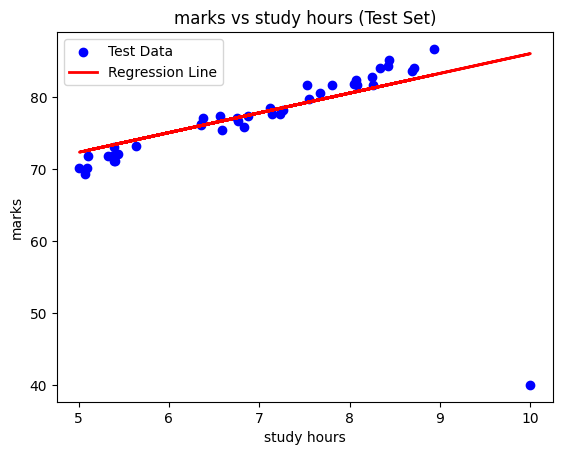

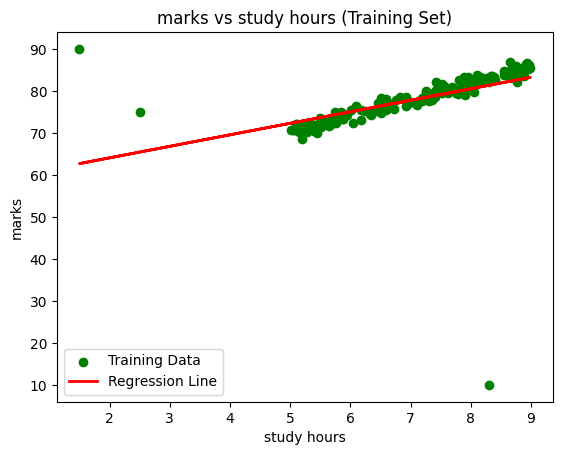

In [ ]:
hours = pd.DataFrame({'study_hours': [7]})
predict_marks = model.predict(hours)
print("\n Predicted marks for 7 hours: {:.2f}".format(predict_marks[0]))
print("\n Mean squared error:", mse)
print("R2 score:", r2)
plt.scatter(x_test, y_test, color='blue', label='Test Data')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('study hours')
plt.ylabel('marks')
plt.title('marks vs study hours (Test Set)')
plt.legend()
plt.show()
plt.scatter(x_train, y_train, color='green', label='Training Data')
plt.plot(x_train, model.predict(x_train), color='red', linewidth=2, label='Regression Line')
plt.title('marks vs study hours (Training Set)')
plt.xlabel('study hours')
plt.ylabel('marks')
plt.legend()
plt.show()